In [1]:
import sys
sys.path.append("..")

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from src.data_loader import SuperconductorDataLoader
from src.preprocessor import DataPreprocessor

In [4]:
sns.set_theme(style="whitegrid")

In [5]:
loader = SuperconductorDataLoader("../data/raw/train.csv")

In [6]:
df = loader.load()
loader.validate(df)
df.head()

Loaded 21263 rows from train.csv
Data validation passed


,number_of_elements,mean_atomic_mass,wtd_mean_atomic_mass,gmean_atomic_mass,wtd_gmean_atomic_mass,entropy_atomic_mass,wtd_entropy_atomic_mass,range_atomic_mass,wtd_range_atomic_mass,std_atomic_mass,wtd_std_atomic_mass,mean_fie,wtd_mean_fie,gmean_fie,wtd_gmean_fie,entropy_fie,wtd_entropy_fie,range_fie,wtd_range_fie,std_fie,wtd_std_fie,mean_atomic_radius,wtd_mean_atomic_radius,gmean_atomic_radius,wtd_gmean_atomic_radius,entropy_atomic_radius,wtd_entropy_atomic_radius,range_atomic_radius,wtd_range_atomic_radius,std_atomic_radius,wtd_std_atomic_radius,mean_Density,wtd_mean_Density,gmean_Density,wtd_gmean_Density,entropy_Density,wtd_entropy_Density,range_Density,wtd_range_Density,std_Density,...,wtd_mean_ElectronAffinity,gmean_ElectronAffinity,wtd_gmean_ElectronAffinity,entropy_ElectronAffinity,wtd_entropy_ElectronAffinity,range_ElectronAffinity,wtd_range_ElectronAffinity,std_ElectronAffinity,wtd_std_ElectronAffinity,mean_FusionHeat,wtd_mean_FusionHeat,gmean_FusionHeat,wtd_gmean_FusionHeat,entropy_FusionHeat,wtd_entropy_FusionHeat,range_FusionHeat,wtd_range_FusionHeat,std_FusionHeat,wtd_std_FusionHeat,mean_ThermalConductivity,wtd_mean_ThermalConductivity,gmean_ThermalConductivity,wtd_gmean_ThermalConductivity,entropy_ThermalConductivity,wtd_entropy_ThermalConductivity,range_ThermalConductivity,wtd_range_ThermalConductivity,std_ThermalConductivity,wtd_std_ThermalConductivity,mean_Valence,wtd_mean_Valence,gmean_Valence,wtd_gmean_Valence,entropy_Valence,wtd_entropy_Valence,range_Valence,wtd_range_Valence,std_Valence,wtd_std_Valence,critical_temp
0,4,88.944468,57.862692,66.361592,36.116612,1.181795,1.062396,122.90607,31.794921,51.968828,53.622535,775.425,1010.268571,718.152900,938.016780,1.305967,0.791488,810.6,735.985714,323.811808,355.562967,160.25,105.514286,136.126003,84.528423,1.259244,1.207040,205,42.914286,75.237540,69.235569,4654.35725,2961.502286,724.953211,53.543811,1.033129,0.814598,8958.571,1579.583429,3306.162897,...,111.727143,60.123179,99.414682,1.159687,0.787382,127.05,80.987143,51.433712,42.558396,6.9055,3.846857,3.479475,1.040986,1.088575,0.994998,12.878,1.744571,4.599064,4.666920,107.756645,61.015189,7.062488,0.621979,0.308148,0.262848,399.97342,57.127669,168.854244,138.517163,2.25,2.257143,2.213364,2.219783,1.368922,1.066221,1,1.085714,0.433013,0.437059,29.0
1,5,92.729214,58.518416,73.132787,36.396602,1.449309,1.057755,122.90607,36.161939,47.094633,53.979870,766.440,1010.612857,720.605511,938.745413,1.544145,0.807078,810.6,743.164286,290.183029,354.963511,161.20,104.971429,141.465215,84.370167,1.508328,1.204115,205,50.571429,67.321319,68.008817,5821.48580,3021.016571,1237.095080,54.095718,1.314442,0.914802,10488.571,1667.383429,3767.403176,...,112.316429,69.833315,101.166398,1.427997,0.838666,127.05,81.207857,49.438167,41.667621,7.7844,3.796857,4.403790,1.035251,1.374977,1.073094,12.878,1.595714,4.473363,4.603000,172.205316,61.372331,16.064228,0.619735,0.847404,0.567706,429.97342,51.413383,198.554600,139.630922,2.00,2.257143,1.888175,2.210679,1.557113,1.047221,2,1.128571,0.632456,0.468606,26.0
2,4,88.944468,57.885242,66.361592,36.122509,1.181795,0.975980,122.90607,35.741099,51.968828,53.656268,775.425,1010.820000,718.152900,939.009036,1.305967,0.773620,810.6,743.164286,323.811808,354.804183,160.25,104.685714,136.126003,84.214573,1.259244,1.132547,205,49.314286,75.237540,67.797712,4654.35725,2999.159429,724.953211,53.974022,1.033129,0.760305,8958.571,1667.383429,3306.162897,...,112.213571,60.123179,101.082152,1.159687,0.786007,127.05,81.207857,51.433712,41.639878,6.9055,3.822571,3.479475,1.037439,1.088575,0.927479,12.878,1.757143,4.599064,4.649635,107.756645,60.943760,7.062488,0.619095,0.308148,0.250477,399.97342,57.127669,168.854244,138.540613,2.25,2.271429,2.213364,2.232679,1.368922,1.029175,1,1.114286,0.433013,0.444697,19.0
3,4,88.944468,57.873967,66.361592,36.119560,1.181795,1.022291,122.90607,33.768010,51.968828,53.639405,775.425,1010.544286,718.152900,938.512777,1.305967,0.783207,810.6,739.575000,323.811808,355

In [7]:
print(f"Shape: {df.shape}")
print(f"\nSpaltennamen (erste 10):\n{list(df.columns[:10])}")
print(f"\nDatentypen:\n{df.dtypes.value_counts()}")
print(f"\nNaN-Werte gesamt: {df.isna().sum().sum()}")

Shape: (21263, 82)

Spaltennamen (erste 10):
['number_of_elements', 'mean_atomic_mass', 'wtd_mean_atomic_mass', 'gmean_atomic_mass', 'wtd_gmean_atomic_mass', 'entropy_atomic_mass', 'wtd_entropy_atomic_mass', 'range_atomic_mass', 'wtd_range_atomic_mass', 'std_atomic_mass']

Datentypen:
float64    79
int64       3
Name: count, dtype: int64

NaN-Werte gesamt: 0


In [8]:
df["critical_temp"].describe()

count    21263.000000
mean        34.421219
std         34.254362
min          0.000210
25%          5.365000
50%         20.000000
75%         63.000000
max        185.000000
Name: critical_temp, dtype: float64

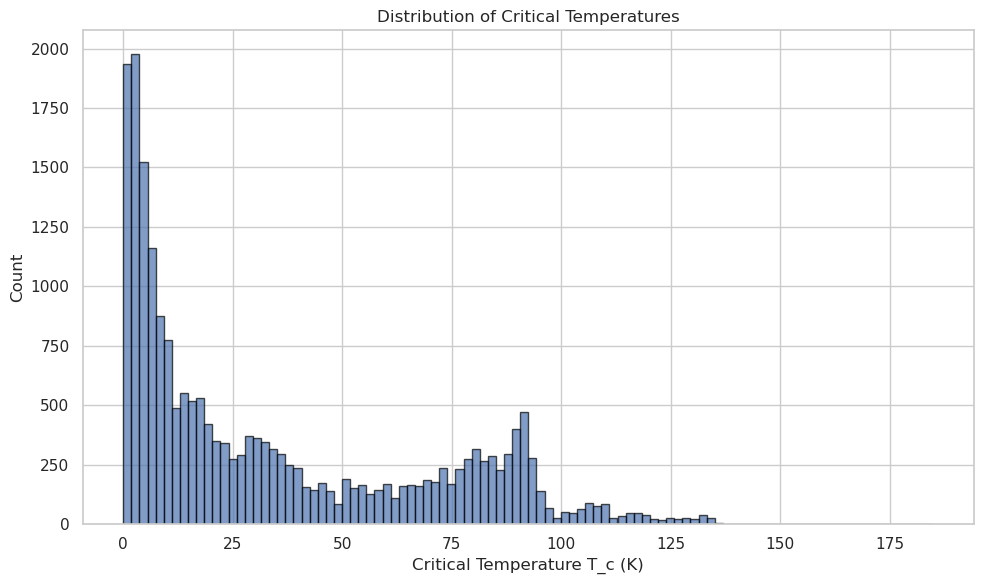

In [9]:
fig, ax = plt.subplots(figsize=(10, 6))
ax.hist(df["critical_temp"], bins=100, edgecolor="black", alpha=0.7)
ax.set_xlabel("Critical Temperature T_c (K)")
ax.set_ylabel("Count")
ax.set_title("Distribution of Critical Temperatures")
plt.tight_layout()
plt.show()

he data frame has 21,263 rows and 82 columns
Min_Tc =  0.000210 K
max_Tc = 185.000 K
mean_Tc = 34.421219 K
The distribution is right-skewed and asymmetric. If one were to consider the small peak around 80 K as equivalent to the one around 2 K, one could speak of a right-skewed bimodal distribution.
This is consistent with Hamidieh's explanations.
Physical interpretation: This second peak at ~80 K corresponds to cuprates (high-temperature superconductors such as YBCO), which have a significantly higher T_c than conventional superconductors.

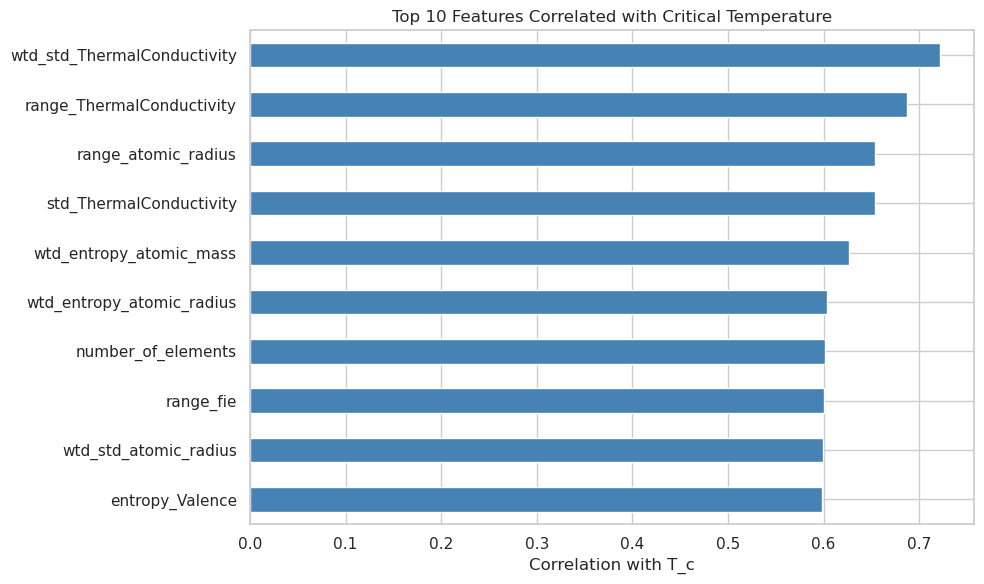

In [10]:
correlations = df.corr()["critical_temp"].sort_values(ascending=False)
top_features = correlations[1:11]  # exclude critical_temp itself

fig, ax = plt.subplots(figsize=(10, 6))
top_features.sort_values().plot(kind="barh", ax=ax, color="steelblue")
ax.set_xlabel("Correlation with T_c")
ax.set_title("Top 10 Features Correlated with Critical Temperature")
plt.tight_layout()
plt.show()

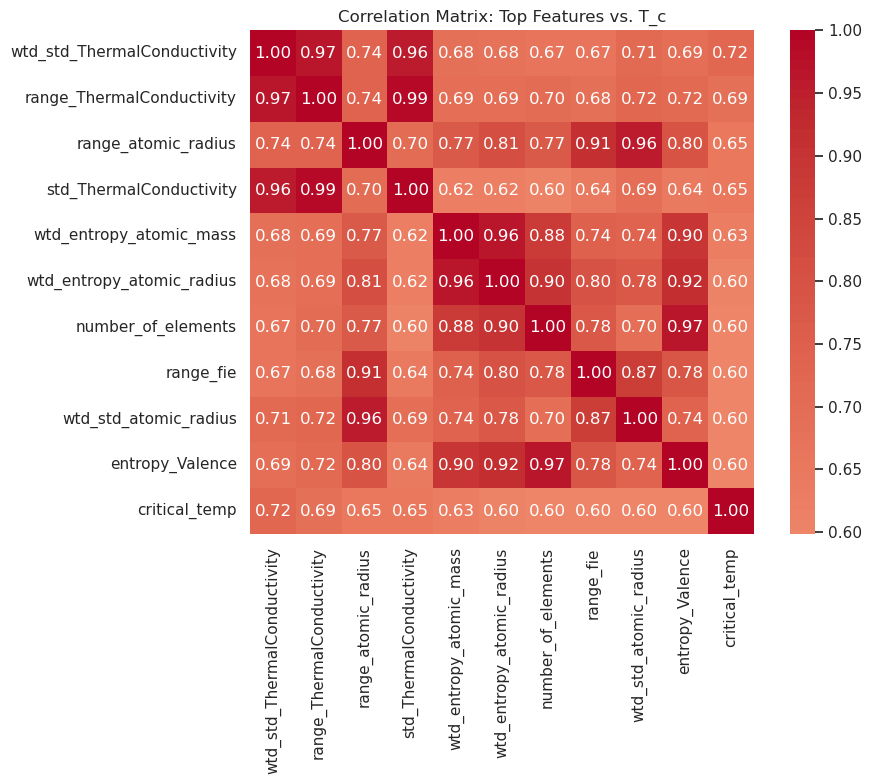

In [11]:
top_cols = list(top_features.index) + ["critical_temp"]
corr_matrix = df[top_cols].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", 
            center=0, ax=ax, square=True)
ax.set_title("Correlation Matrix: Top Features vs. T_c")
plt.tight_layout()
plt.show()

In [18]:
corr_matrix_full = df.corr()
corr_with_target = corr_matrix_full["critical_temp"].sort_values(ascending=False)
pd.set_option("display.max_rows", None)

corr_abs = corr_with_target[1:].abs().sort_values(ascending=False)
corr_abs

wtd_std_ThermalConductivity        0.721271
range_ThermalConductivity          0.687654
range_atomic_radius                0.653759
std_ThermalConductivity            0.653632
wtd_mean_Valence                   0.632401
wtd_entropy_atomic_mass            0.626930
wtd_gmean_Valence                  0.615653
wtd_entropy_atomic_radius          0.603494
number_of_elements                 0.601069
range_fie                          0.600790
mean_Valence                       0.600085
wtd_std_atomic_radius              0.599199
entropy_Valence                    0.598591
wtd_entropy_Valence                0.589664
wtd_std_fie                        0.582013
gmean_Valence                      0.573068
entropy_fie                        0.567817
wtd_entropy_FusionHeat             0.563244
std_atomic_radius                  0.559629
entropy_atomic_radius              0.558937
entropy_FusionHeat                 0.552709
entropy_atomic_mass                0.543619
std_fie                         

In [19]:
pd.reset_option("display.max_rows")

### Physical Interpretation of the Features Most Strongly Correlated with T_c

The features most strongly correlated with T_c can all 
be explained in terms of solid-state physics:

1. **Thermal conductivity (wtd_std, range, std)**: 
   In BCS theory, superconductivity is a phonon-mediated Cooper pair formation. 
   Thermal conductivity is directly linked to phonon transport — high scattering (std) indicates a variety of phonon modes, which promotes electron-phonon coupling.

2. **Atomic radius**: 
   Determines the lattice constant and thus the overlap of the electron shells. 
   Larger atomic radii result in broader bands and alter the density of states at the Fermi edge (DOS), which is directly incorporated into the BCS formula for T_c.


3. **Valence electrons**: 
   The number of valence electrons determines the electronic band structure 
   and the DOS at the Fermi edge. Higher DOS → more pair formation → higher T_c.

4. **Atomic mass**: 
   In the BCS model, the isotope effect holds: T_c $\propto 1/\sqrt M$. 
   Heavier atoms → lower phonon frequencies → lower T_c.

5. **Number of elements**: 
   More complex compounds (especially cuprates with 4 or more elements) 
   achieve higher T_c — which explains high-temperature superconductivity.


In [20]:
df_mat = pd.read_csv("../data/raw/unique_m.csv")
df_mat.head()

,H,He,Li,Be,B,C,N,O,F,Ne,Na,Mg,Al,Si,P,S,Cl,Ar,K,Ca,Sc,Ti,V,Cr,Mn,Fe,Co,Ni,Cu,Zn,Ga,Ge,As,Se,Br,Kr,Rb,Sr,Y,Zr,...,In,Sn,Sb,Te,I,Xe,Cs,Ba,La,Ce,Pr,Nd,Pm,Sm,Eu,Gd,Tb,Dy,Ho,Er,Tm,Yb,Lu,Hf,Ta,W,Re,Os,Ir,Pt,Au,Hg,Tl,Pb,Bi,Po,At,Rn,critical_temp,material
0,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.20,1.80,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,29.0,Ba0.2La1.8Cu1O4
1,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.9,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.10,1.90,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,26.0,Ba0.1La1.9Ag0.1Cu0.9O4
2,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.10,1.90,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,19.0,Ba0.1La1.9Cu1O4
3,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.15,1.85,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,22.0,Ba0.15La1.85Cu1O4
4,0.0,0,0.0,0.0,0.0,0.0,0.0,4.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0,0.0,0.30,1.70,0.0,0.0,0.0,0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0,0,0,23.0,Ba0.3La1.7Cu1O4


In [21]:
df_mat.shape

(21263, 88)

In [22]:
# T_c aus dem originalen DataFrame übernehmen
df_mat["critical_temp"] = df["critical_temp"]

# Materialklasse: Cuprat (enthält Cu)?
df_mat["is_cuprate"] = (df_mat["Cu"] > 0) & (df_mat["O"] > 0)

# Eisenpniktid (enthält Fe und As/Se)?
df_mat["is_iron_pnictide"] = (df_mat["Fe"] > 0) & ((df_mat["As"] > 0) | (df_mat["Se"] > 0))

# Anzahl der Elemente pro Material
element_columns = df_mat.columns[:87]
df_mat["n_elements"] = (df_mat[element_columns] > 0).sum(axis=1)

# Überblick
print(f"Cuprate: {df_mat['is_cuprate'].sum()} Materialien")
print(f"Eisenpniktide: {df_mat['is_iron_pnictide'].sum()} Materialien")
print(f"Andere: {(~df_mat['is_cuprate'] & ~df_mat['is_iron_pnictide']).sum()} Materialien")

Cuprate: 10532 Materialien
Eisenpniktide: 1682 Materialien
Andere: 9049 Materialien
